In [2]:
import pathlib
import re
import anndata as ad  # assuming ad is anndata

pattern = re.compile(r"\d{2}-\d{2}\.h5ad")

adata_dict = {
    folder.name[:-5]: ad.read_h5ad(folder)
    for folder in pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/adata/mapped_pathology_data").glob("*.h5ad")
    if pattern.fullmatch(folder.name)
}

In [35]:
import pandas as pd
plin2 = {
    folder.name[:-4]: pd.read_csv(folder)
    for folder in pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/locations/plin2").glob("*.csv")
}

oro = {
    folder.name[:-4]: pd.read_csv(folder)
    for folder in pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/locations/oil-red-o").glob("*.csv")
}

lipid_droplet = {
    folder.name[:-4]: pd.read_csv(folder)
    for folder in pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/locations/lipid-droplet").glob("*.csv")
}

In [29]:
for folder in adata_dict:
    print(adata_dict[folder].obs["plin2_area"].sum() / plin2[folder].area.sum())

0.14323244457047477
0.12786470414170734
0.16852386980643325
0.16623142851347875
0.1296866623369184
0.1084832823885898
0.20817996167430133
0.11951887199105947
0.16792384066231322
0.11309173749481209
0.17666476061115263
0.1742238174748678


In [32]:
for folder in adata_dict:
    print(adata_dict[folder].obs["oil_red_o_area"].sum() / oro[folder].area.sum())

0.13810148730142455
0.09680689400053871
0.16139998530419483
0.16586713231800554
0.13057145875554216
0.12938831792343577
0.2065767389025178
0.1317308246772756
0.16558886428287917
0.12271219464331629
0.17012308289746675
0.15271847082225062


In [43]:
stats = pd.DataFrame()
stats["oil_red_o"] = {
    folder: adata_dict[folder].obs["oil_red_o_area"].sum() / oro[folder].area.sum()
    for folder in adata_dict
}

stats["plin2"] = {
    folder: adata_dict[folder].obs["plin2_area"].sum() / plin2[folder].area.sum()
    for folder in adata_dict
}

stats["lipid_droplet"] = {
    folder: adata_dict[folder].obs["lipid_droplet_area"].sum() / lipid_droplet[folder].area.sum()
    for folder in adata_dict
}

stats.loc["mean"] = stats.mean(axis=0)

# Instance Segmentation Masks

In [57]:
instance_segmentations = pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/warped_segmentation/plin2")

In [58]:
import tifffile
image = tifffile.imread(instance_segmentations / "05-27.tif")

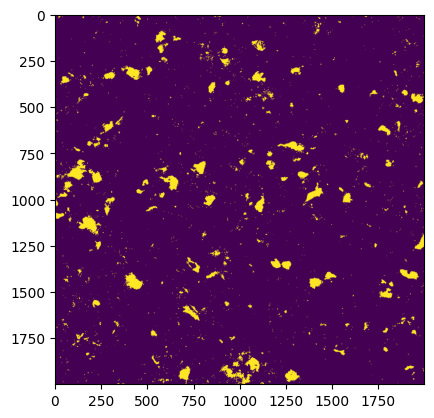

In [64]:
import matplotlib.pyplot as plt
plt.imshow(image[10000:12000, 10000:12000])